# CCLE Dataset: EDA, QC, and Model Preparation

This notebook prepares CCLE RNA expression data for predicting **TP53 mutation status** from transcriptomic features.

## Goals of this notebook
1. Load expression, mutation, and model metadata
2. Build transparent TP53 mutation labels with multiple strictness levels
3. Split train / validation / test early to reduce leakage risk
4. Filter low-information genes using the training split only
5. Inspect gene-level TP53 associations and candidate QC issues
6. Build interpretable and baseline feature sets for downstream models
7. Quantify lineage confounding before modeling

## Important scope note
This notebook is mainly for **data understanding and modeling preparation**, not final biological interpretation.

In CCLE, TP53 status can be confounded by **lineage / tissue composition**, so strong-looking gene differences do not automatically mean TP53-specific biology. Later modeling should always be compared against a **lineage-only baseline**.


## 0. Setup

In [1]:
from pathlib import Path
from IPython.display import display

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
from scipy import stats
import sklearn
import statsmodels

from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

RNG = 42
DATA_DIR = Path("data")
OUT_DIR = Path("processed")
OUT_DIR.mkdir(exist_ok=True, parents=True)

MODEL_PATH = DATA_DIR / "Model.csv"
MUT_PATH = DATA_DIR / "OmicsSomaticMutations.csv"
EXPR_PATH = DATA_DIR / "OmicsExpressionProteinCodingGenesTPMLogp1.csv"

CONFIG = {
    "detect_expr_threshold": 0.10,
    "min_detect_frac": 0.05,
    "min_variance": 1e-4,
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features": 300,
    "outlier_vote_possible": 3,
    "outlier_vote_sure": 4,
    "outlier_contamination": 0.05,
    "max_pca_components": 100,
    "min_lineage_n_report": 15,
}

for path in [MODEL_PATH, MUT_PATH, EXPR_PATH]:
    assert path.exists(), f"Missing file: {path}"


def choose_first_present(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def collapse_duplicate_gene_columns(df):
    n_dup = int(df.columns.duplicated().sum())
    if n_dup == 0:
        return df, 0
    collapsed = df.T.groupby(level=0).mean().T
    return collapsed, n_dup


def robust_zscore(values):
    s = pd.Series(values, copy=True)
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad == 0 or pd.isna(mad):
        return pd.Series(0.0, index=s.index)
    return 0.6745 * (s - med) / mad


def mad_flag(values, threshold=3.5):
    return robust_zscore(values).abs() > threshold


TP53_TEXT_COLS = [
    "VariantClassification",
    "VariantInfo",
    "VariantType",
    "ProteinChange",
    "HGVSp_Short",
    "HGVSp",
    "RefSeq",
]


def classify_tp53_event(row):
    vc = str(row.get("VariantClassification", "")).strip().lower()
    vt = str(row.get("VariantType", "")).strip().lower()
    text = " ".join(str(row.get(c, "")) for c in TP53_TEXT_COLS).lower()

    if vc in {
        "frame_shift_del", "frame_shift_ins", "frameshift_deletion", "frameshift_insertion",
        "nonsense_mutation", "splice_site", "translation_start_site",
        "start_codon_del", "start_codon_ins", "stop_codon_del", "stop_codon_ins",
    }:
        return "lof_or_splice"

    if vc in {"missense_mutation", "in_frame_del", "in_frame_ins"}:
        return "missense_or_inframe"

    if vc in {"silent", "synonymous"}:
        return "synonymous"

    lof_terms = [
        "frameshift", "frame_shift", "nonsense", "stop_gained", "stopgain",
        "splice", "start_lost", "stop_lost", "trunc", "truncating",
    ]
    missense_terms = [
        "missense", "nonsynonymous", "non_synonymous", "inframe", "in_frame",
        "nonframeshift", "non_frameshift",
    ]
    syn_terms = ["synonymous", "silent"]

    if any(term in text for term in lof_terms):
        return "lof_or_splice"
    if any(term in text for term in missense_terms):
        return "missense_or_inframe"
    if any(term in text for term in syn_terms):
        return "synonymous"
    if vc:
        return "other_or_unknown"
    if vt in {"snp", "dnp", "tnp", "onp", "del", "ins"}:
        return "other_or_unknown"
    return "unknown"


def corr_against_binary(X, y, method="pearson"):
    assert X.index.equals(y.index), "X and y must have aligned indices."

    y_vec = y.astype(float).to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r**2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


print(
    f"pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__} | "
    f"sklearn {sklearn.__version__} | statsmodels {statsmodels.__version__}"
)
print(json.dumps(CONFIG, indent=2))


pandas 3.0.2 | numpy 2.4.4 | scipy 1.17.1 | sklearn 1.8.0 | statsmodels 0.14.6
{
  "detect_expr_threshold": 0.1,
  "min_detect_frac": 0.05,
  "min_variance": 0.0001,
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features": 300,
  "outlier_vote_possible": 3,
  "outlier_vote_sure": 4,
  "outlier_contamination": 0.05,
  "max_pca_components": 100,
  "min_lineage_n_report": 15
}


## 1. Load data, keep useful metadata, and build TP53 labels

We load:

- `Model.csv` for lineage / disease metadata
- somatic mutation calls
- protein-coding expression matrix

We then build several TP53 labels:

- **TP53_mut_any**: any TP53 call in the mutation table
- **TP53_mut_nonsyn**: missense / inframe or LoF / splice calls only
- **TP53_mut_lof**: LoF / splice only

This lets us test whether results are robust to how aggressively we define the mutant class.


In [2]:
model = pd.read_csv(MODEL_PATH)
muts = pd.read_csv(MUT_PATH, low_memory=False)
expr = pd.read_csv(EXPR_PATH, index_col=0)

assert "ModelID" in muts.columns, "Expected ModelID in mutation file."
assert "HugoSymbol" in muts.columns, "Expected HugoSymbol in mutation file."

expr.index.name = "ModelID"
expr.columns = expr.columns.str.replace(r"\s*\([^)]*\)$", "", regex=True)
expr, n_collapsed_gene_names = collapse_duplicate_gene_columns(expr)

lineage_col = choose_first_present(
    model.columns,
    ["OncotreeLineage", "OncotreeLineageDerived", "Lineage", "lineage"],
)
disease_col = choose_first_present(
    model.columns,
    ["OncotreePrimaryDisease", "PrimaryDisease", "Primary Disease", "Disease"],
)
name_col = choose_first_present(
    model.columns,
    ["StrippedCellLineName", "CellLineName", "ModelName", "CCLEName"],
)

model_keep = ["ModelID"] + [c for c in [name_col, lineage_col, disease_col] if c is not None]
model_meta = model[model_keep].drop_duplicates("ModelID").set_index("ModelID")

expr_ids = pd.Index(expr.index.unique(), name="ModelID")
mut_ids = pd.Index(pd.Series(muts["ModelID"].dropna().unique()).sort_values(), name="ModelID")
model_ids = pd.Index(model_meta.index.unique(), name="ModelID")

overlap_summary = pd.Series(
    {
        "expression_samples": len(expr_ids),
        "mutation_covered_samples": len(mut_ids),
        "metadata_samples": len(model_ids),
        "expr_and_mut_overlap": len(expr_ids.intersection(mut_ids)),
        "expr_and_meta_overlap": len(expr_ids.intersection(model_ids)),
        "mut_and_meta_overlap": len(mut_ids.intersection(model_ids)),
        "expr_mut_meta_overlap": len(expr_ids.intersection(mut_ids).intersection(model_ids)),
    },
    name="n",
)

print(f"Model:      {model.shape}")
print(f"Mutations:  {muts.shape}")
print(f"Expression: {expr.shape}")
print(f"Collapsed duplicate gene symbols after stripping suffixes: {n_collapsed_gene_names}")
print(f"Model metadata columns kept: {[c for c in model_keep if c != 'ModelID']}")
print(f"Expression ModelIDs unique: {expr.index.is_unique}")

print("\nSample overlap summary:")
display(overlap_summary.to_frame())

if lineage_col is not None:
    print(f"Missing {lineage_col}: {model_meta[lineage_col].isna().sum():,} / {len(model_meta):,}")
if disease_col is not None:
    print(f"Missing {disease_col}: {model_meta[disease_col].isna().sum():,} / {len(model_meta):,}")


Model:      (2116, 49)
Mutations:  (751310, 70)
Expression: (1684, 19205)
Collapsed duplicate gene symbols after stripping suffixes: 0
Model metadata columns kept: ['StrippedCellLineName', 'OncotreeLineage', 'OncotreePrimaryDisease']
Expression ModelIDs unique: True

Sample overlap summary:


,n
expression_samples,1684
mutation_covered_samples,1939
metadata_samples,2116
expr_and_mut_overlap,1608
expr_and_meta_overlap,1684
mut_and_meta_overlap,1939
expr_mut_meta_overlap,1608


Missing OncotreeLineage: 10 / 2,116
Missing OncotreePrimaryDisease: 0 / 2,116


In [4]:
tp53_muts = muts.loc[muts["HugoSymbol"].eq("TP53")].copy()
tp53_muts["tp53_event_class"] = tp53_muts.apply(classify_tp53_event, axis=1)

priority_map = {
    "lof_or_splice": 5,
    "missense_or_inframe": 4,
    "other_or_unknown": 3,
    "synonymous": 2,
    "unknown": 1,
}
tp53_muts["priority"] = tp53_muts["tp53_event_class"].map(priority_map).fillna(0).astype(int)

best_tp53 = (
    tp53_muts.sort_values(["ModelID", "priority"], ascending=[True, False])
    .drop_duplicates("ModelID", keep="first")
    .set_index("ModelID")
)

called_ids = set(muts["ModelID"].dropna().unique())
expr_ids = set(expr.index)
common = sorted(called_ids & expr_ids)

X_all = expr.loc[common].copy()

sample_meta = pd.DataFrame(index=common).join(model_meta, how="left")
sample_meta["TP53_event_class"] = best_tp53["tp53_event_class"].reindex(common)
sample_meta["tp53_event_count"] = tp53_muts.groupby("ModelID").size().reindex(common).fillna(0).astype(int)

sample_meta["TP53_mut_any"] = sample_meta.index.isin(best_tp53.index).astype(int)
sample_meta["TP53_mut_nonsyn"] = sample_meta["TP53_event_class"].isin(
    ["lof_or_splice", "missense_or_inframe"]
).astype(int)
sample_meta["TP53_mut_lof"] = sample_meta["TP53_event_class"].eq("lof_or_splice").astype(int)
sample_meta["TP53_mut_ambiguous"] = sample_meta["TP53_event_class"].isin(
    ["other_or_unknown", "unknown", "synonymous"]
).astype(int)

mut_type = sample_meta["TP53_event_class"].fillna("wild_type").rename("mut_type")

y_all = sample_meta["TP53_mut_any"].rename("TP53_mut")
y_all_nonsyn = sample_meta["TP53_mut_nonsyn"].rename("TP53_mut_nonsyn")
y_all_lof = sample_meta["TP53_mut_lof"].rename("TP53_mut_lof")

print(f"Usable samples with mutation-call coverage and expression: {len(common):,}")
print(f"TP53 mutant (any TP53 call):              {int(y_all.sum()):,} ({y_all.mean():.1%})")
print(f"TP53 mutant (nonsynonymous-like only):    {int(y_all_nonsyn.sum()):,} ({y_all_nonsyn.mean():.1%})")
print(f"TP53 mutant (LoF / splice only):          {int(y_all_lof.sum()):,} ({y_all_lof.mean():.1%})")
print(f"Cell lines with >1 TP53 event:            {(sample_meta['tp53_event_count'] > 1).sum():,}")

event_counts = (
    sample_meta["TP53_event_class"]
    .fillna("wild_type")
    .value_counts(dropna=False)
    .rename_axis("event_class")
    .to_frame("n_cell_lines")
)
display(event_counts)

debug_cols_preferred = [
    "ModelID",
    "VariantClassification",
    "VariantType",
    "ProteinChange",
    "HGVSp_Short",
    "HGVSp",
    "VariantInfo",
    "RefSeq",
    "tp53_event_class",
]
debug_cols = [c for c in debug_cols_preferred if c in tp53_muts.columns]

ambiguous_examples = tp53_muts.loc[
    tp53_muts["tp53_event_class"].isin(["other_or_unknown", "unknown", "synonymous"]),
    debug_cols
].head(15)

if len(ambiguous_examples) > 0:
    print("Examples of TP53 calls not counted in the stricter labels:")
    display(ambiguous_examples)

Usable samples with mutation-call coverage and expression: 1,608
TP53 mutant (any TP53 call):              987 (61.4%)
TP53 mutant (nonsynonymous-like only):    987 (61.4%)
TP53 mutant (LoF / splice only):          362 (22.5%)
Cell lines with >1 TP53 event:            115


,n_cell_lines
event_class,
missense_or_inframe,625
wild_type,621
lof_or_splice,362


## 2. Train / validation / test split

We split **before** filtering, correlation analysis, QC, and feature selection.

All downstream preprocessing is fit on the **training split only**, then applied to validation and test.

This random stratified split is a reasonable baseline, but in CCLE it is not enough by itself because **lineage / tissue can confound TP53 status**. We measure that explicitly later.


In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.15,
    stratify=y_all,
    random_state=RNG,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.15 / 0.85,
    stratify=y_temp,
    random_state=RNG,
)

split_membership = pd.Series(index=X_all.index, dtype="object")
split_membership.loc[X_train.index] = "train"
split_membership.loc[X_val.index] = "val"
split_membership.loc[X_test.index] = "test"
sample_meta["split"] = split_membership

split_summary = pd.DataFrame(
    {
        "n": [len(y_train), len(y_val), len(y_test)],
        "tp53_mut_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "val", "test"],
)
display(split_summary.round(3))

if lineage_col is not None and sample_meta[lineage_col].notna().any():
    print(f"Top {lineage_col} groups by split:")
    lineage_by_split = (
        sample_meta.loc[X_all.index, ["split", lineage_col]]
        .assign(**{lineage_col: lambda d: d[lineage_col].fillna("Unknown")})
        .groupby(["split", lineage_col])
        .size()
        .rename("n")
        .reset_index()
    )

    for split_name in ["train", "val", "test"]:
        print(f"\n{split_name.upper()}:")
        display(
            lineage_by_split.loc[lineage_by_split["split"].eq(split_name)]
            .sort_values("n", ascending=False)
            .head(10)
            .set_index(lineage_col)[["n"]]
        )


,n,tp53_mut_rate
train,1124,0.614
val,242,0.612
test,242,0.616


Top OncotreeLineage groups by split:

TRAIN:


,n
OncotreeLineage,
Lung,148
Lymphoid,128
Skin,77
CNS/Brain,68
Esophagus/Stomach,56
Bowel,54
Myeloid,50
Breast,50
Head and Neck,50



VAL:


,n
OncotreeLineage,
Lymphoid,38
Lung,29
Skin,21
CNS/Brain,13
Ovary/Fallopian Tube,12
Bowel,11
Esophagus/Stomach,11
Myeloid,11
Soft Tissue,10



TEST:


,n
OncotreeLineage,
Lung,22
Skin,21
Bowel,19
Lymphoid,18
CNS/Brain,14
Pancreas,13
Head and Neck,13
Ovary/Fallopian Tube,12
Soft Tissue,11


## 3. Training-set-only low-information filtering and per-gene summary

Before correlation and QC, we remove genes that are effectively uninformative on the training set.

A gene is kept only if it has:

- enough detected expression across training samples
- non-trivial variance across training samples

This usually fixes constant-feature problems, stabilizes correlation estimates, and reduces noise in later steps.

Genes before filtering: 19,205
Genes after filtering:  17,764
Removed low-information genes: 1,441


,n_genes
fail_detect_frac_only,1307
fail_variance_only,0
fail_both,134


Genes with higher mean in MUT: 62.9%
Genes with lower zero% in MUT: 45.6%
Interpretation note: large mean shifts can reflect TP53 biology, lineage composition, or both.


,mean_mut,mean_wt,std_mut,std_wt,zero_mut,zero_wt,delta_mean
EPCAM,5.254,2.699,3.645,3.201,0.029,0.088,2.555
SPINT2,6.388,4.130,3.310,3.407,0.009,0.025,2.258
KRT19,5.593,3.507,4.137,3.924,0.045,0.150,2.086
CLDN7,4.211,2.125,3.186,2.751,0.017,0.088,2.086
VIM,6.585,8.656,3.805,3.492,0.001,0.007,-2.071
CLDN4,4.673,2.606,3.428,2.949,0.001,0.014,2.067
CDKN1A,4.721,6.760,1.687,1.554,0.000,0.000,-2.039
KRT8,7.576,5.557,3.617,3.858,0.013,0.023,2.020
TACSTD2,3.708,1.692,3.797,2.945,0.084,0.184,2.016
MAL2,4.524,2.576,3.445,3.082,0.038,0.111,1.948


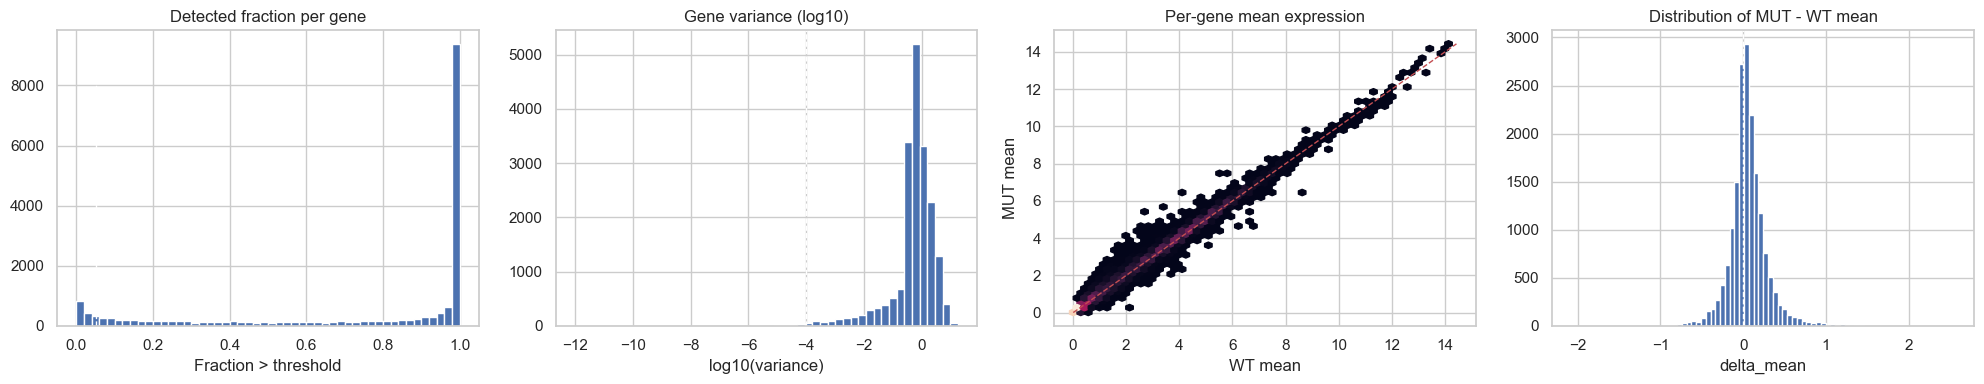

In [6]:
detected_frac = (X_train > CONFIG["detect_expr_threshold"]).mean(axis=0)
variance = X_train.var(axis=0, ddof=1)

keep_gene_mask = (
    (detected_frac >= CONFIG["min_detect_frac"])
    & (variance >= CONFIG["min_variance"])
)

gene_filter_qc = pd.DataFrame(
    {
        "detected_frac": detected_frac,
        "variance": variance,
        "fail_detect_frac": detected_frac < CONFIG["min_detect_frac"],
        "fail_variance": variance < CONFIG["min_variance"],
        "keep": keep_gene_mask,
    }
).sort_values(["keep", "variance", "detected_frac"], ascending=[False, False, False])

X_train_filt = X_train.loc[:, keep_gene_mask].copy()
X_val_filt = X_val.loc[:, keep_gene_mask].copy()
X_test_filt = X_test.loc[:, keep_gene_mask].copy()

print(f"Genes before filtering: {X_train.shape[1]:,}")
print(f"Genes after filtering:  {X_train_filt.shape[1]:,}")
print(f"Removed low-information genes: {(~keep_gene_mask).sum():,}")

removal_summary = pd.Series(
    {
        "fail_detect_frac_only": int((gene_filter_qc["fail_detect_frac"] & ~gene_filter_qc["fail_variance"]).sum()),
        "fail_variance_only": int((gene_filter_qc["fail_variance"] & ~gene_filter_qc["fail_detect_frac"]).sum()),
        "fail_both": int((gene_filter_qc["fail_detect_frac"] & gene_filter_qc["fail_variance"]).sum()),
    },
    name="n_genes",
)
display(removal_summary.to_frame())


def gene_stats(X, y, label):
    Xg = X.loc[y == label]
    return pd.DataFrame(
        {
            "mean": Xg.mean(),
            "median": Xg.median(),
            "std": Xg.std(ddof=1),
            "zero_pct": (Xg == 0).mean(),
        }
    )


s_mut = gene_stats(X_train_filt, y_train, 1)
s_wt = gene_stats(X_train_filt, y_train, 0)

cmp = pd.DataFrame(
    {
        "mean_mut": s_mut["mean"],
        "mean_wt": s_wt["mean"],
        "median_mut": s_mut["median"],
        "median_wt": s_wt["median"],
        "std_mut": s_mut["std"],
        "std_wt": s_wt["std"],
        "zero_mut": s_mut["zero_pct"],
        "zero_wt": s_wt["zero_pct"],
    }
)
cmp["delta_mean"] = cmp["mean_mut"] - cmp["mean_wt"]
cmp["delta_median"] = cmp["median_mut"] - cmp["median_wt"]
cmp["delta_zero"] = cmp["zero_mut"] - cmp["zero_wt"]
cmp["abs_delta_mean"] = cmp["delta_mean"].abs()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(gene_filter_qc["detected_frac"], bins=50)
axes[0].axvline(CONFIG["min_detect_frac"], linestyle="--", linewidth=1)
axes[0].set_title("Detected fraction per gene")
axes[0].set_xlabel("Fraction > threshold")

axes[1].hist(np.log10(gene_filter_qc["variance"] + 1e-12), bins=50)
axes[1].axvline(np.log10(CONFIG["min_variance"]), linestyle="--", linewidth=1)
axes[1].set_title("Gene variance (log10)")
axes[1].set_xlabel("log10(variance)")

axes[2].hexbin(cmp["mean_wt"], cmp["mean_mut"], gridsize=50, mincnt=1)
lims = [
    float(cmp[["mean_wt", "mean_mut"]].min().min()),
    float(cmp[["mean_wt", "mean_mut"]].max().max()),
]
axes[2].plot(lims, lims, "r--", linewidth=1)
axes[2].set_xlabel("WT mean")
axes[2].set_ylabel("MUT mean")
axes[2].set_title("Per-gene mean expression")

axes[3].hist(cmp["delta_mean"], bins=80)
axes[3].axvline(0, linestyle="--", linewidth=1)
axes[3].set_title("Distribution of MUT - WT mean")
axes[3].set_xlabel("delta_mean")

plt.tight_layout()

print(f"Genes with higher mean in MUT: {(cmp['delta_mean'] > 0).mean():.1%}")
print(f"Genes with lower zero% in MUT: {(cmp['delta_zero'] < 0).mean():.1%}")
print("Interpretation note: large mean shifts can reflect TP53 biology, lineage composition, or both.")

display(
    cmp.sort_values("abs_delta_mean", ascending=False)
    .head(20)[["mean_mut", "mean_wt", "std_mut", "std_wt", "zero_mut", "zero_wt", "delta_mean"]]
    .round(3)
)


## 4. Univariate association with TP53 status

We quantify per-gene association with the training-set TP53 label using both:

- Pearson correlation
- Spearman correlation

We apply Benjamini–Hochberg correction to each set of p-values and inspect agreement between the two rankings.

Low-information genes have already been filtered out, so constant-feature failures should no longer dominate this section.

In [7]:
corr_pearson = corr_against_binary(X_train_filt, y_train, method="pearson")
corr_spearman = corr_against_binary(X_train_filt, y_train, method="spearman")

corr = corr_pearson.join(corr_spearman)
corr["abs_pearson_r"] = corr["pearson_r"].abs()
corr["abs_spearman_r"] = corr["spearman_r"].abs()
corr = corr.sort_values("abs_pearson_r", ascending=False)

effect_summary = pd.Series(
    {
        "genes_tested": int(corr["pearson_r"].notna().sum()),
        "pearson_bh_sig": int((corr["pearson_p_bh"] <= CONFIG["corr_alpha"]).sum()),
        "spearman_bh_sig": int((corr["spearman_p_bh"] <= CONFIG["corr_alpha"]).sum()),
        "abs_pearson_r_ge_0.10": int((corr["abs_pearson_r"] >= 0.10).sum()),
        "abs_pearson_r_ge_0.15": int((corr["abs_pearson_r"] >= 0.15).sum()),
        "abs_pearson_r_ge_0.20": int((corr["abs_pearson_r"] >= 0.20).sum()),
    },
    name="n_genes",
)
display(effect_summary.to_frame())

print("Top positively associated genes:")
display(
    corr.sort_values("pearson_r", ascending=False)
    .head(15)[["pearson_r", "pearson_p", "pearson_p_bh", "spearman_r", "spearman_p", "spearman_p_bh"]]
    .assign(
        pearson_p=lambda d: d["pearson_p"].map(lambda x: f"{x:.2e}"),
        pearson_p_bh=lambda d: d["pearson_p_bh"].map(lambda x: f"{x:.2e}"),
        spearman_p=lambda d: d["spearman_p"].map(lambda x: f"{x:.2e}"),
        spearman_p_bh=lambda d: d["spearman_p_bh"].map(lambda x: f"{x:.2e}"),
    )
)

print("Top negatively associated genes:")
display(
    corr.sort_values("pearson_r", ascending=True)
    .head(15)[["pearson_r", "pearson_p", "pearson_p_bh", "spearman_r", "spearman_p", "spearman_p_bh"]]
    .assign(
        pearson_p=lambda d: d["pearson_p"].map(lambda x: f"{x:.2e}"),
        pearson_p_bh=lambda d: d["pearson_p_bh"].map(lambda x: f"{x:.2e}"),
        spearman_p=lambda d: d["spearman_p"].map(lambda x: f"{x:.2e}"),
        spearman_p_bh=lambda d: d["spearman_p_bh"].map(lambda x: f"{x:.2e}"),
    )
)

print("Interpretation note: significance counts are inflated by sample size and lineage structure, so effect sizes matter more than raw BH counts.")


,n_genes
genes_tested,17764
pearson_bh_sig,8713
spearman_bh_sig,9624
abs_pearson_r_ge_0.10,5414
abs_pearson_r_ge_0.15,2252
abs_pearson_r_ge_0.20,743


Top positively associated genes:


,pearson_r,pearson_p,pearson_p_bh,spearman_r,spearman_p,spearman_p_bh
EPCAM,0.336779,3.28e-31,3.07e-28,0.350430,8.08e-34,7.18e-31
NSUN7,0.333187,1.52e-30,1.35e-27,0.332746,1.83e-30,1.05e-27
CDC42BPG,0.319232,4.81e-28,3.56e-25,0.333493,1.33e-30,7.90e-28
CLDN7,0.318435,6.62e-28,4.71e-25,0.334144,1.01e-30,6.20e-28
CNKSR1,0.318074,7.65e-28,5.23e-25,0.352752,2.82e-34,2.95e-31
PLS1,0.316185,1.63e-27,1.07e-24,0.319382,4.53e-28,1.75e-25
SPINT2,0.312286,7.56e-27,4.80e-24,0.312813,6.15e-27,1.95e-24
RCE1,0.311101,1.20e-26,7.36e-24,0.325924,3.16e-29,1.48e-26
OVOL2,0.310641,1.44e-26,8.51e-24,0.344279,1.26e-32,9.30e-30
MAP3K9,0.310505,1.51e-26,8.68e-24,0.309332,2.39e-26,6.84e-24


Top negatively associated genes:


,pearson_r,pearson_p,pearson_p_bh,spearman_r,spearman_p,spearman_p_bh
EDA2R,-0.621463,4.57e-121,8.11e-117,-0.558122,4.94e-93,4.38e-89
MDM2,-0.536556,8.41e-85,7.47e-81,-0.561563,2.11e-94,3.74e-90
RPS27L,-0.527796,1.26e-81,7.47e-78,-0.534301,5.63e-84,2.50e-80
ZMAT3,-0.526673,3.17e-81,1.41e-77,-0.519205,1.34e-78,4.76e-75
CDKN1A,-0.518769,1.90e-78,6.74e-75,-0.550834,3.49e-90,2.06e-86
RRM2B,-0.418730,6.09e-49,1.80e-45,-0.414145,8.23e-48,1.83e-44
SESN1,-0.414226,7.86e-48,1.99e-44,-0.434828,4.73e-53,1.20e-49
BAX,-0.407297,3.72e-46,8.27e-43,-0.408969,1.48e-46,2.63e-43
PTCHD4,-0.403850,2.46e-45,4.85e-42,-0.436554,1.66e-53,4.92e-50
FDXR,-0.398589,4.19e-44,7.43e-41,-0.400766,1.30e-44,1.93e-41


Interpretation note: significance counts are inflated by sample size and lineage structure, so effect sizes matter more than raw BH counts.


Correlation between |Pearson| and |Spearman|: 0.865
Genes significant by both tests: 7,801


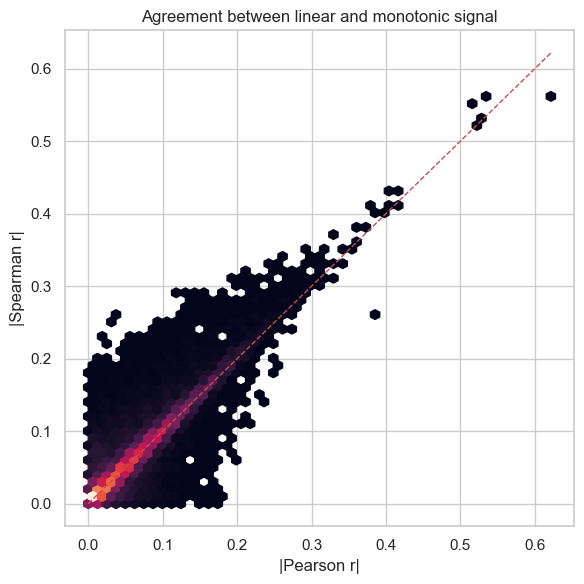

In [8]:
valid_corr = corr[["abs_pearson_r", "abs_spearman_r"]].dropna()

fig, ax = plt.subplots(figsize=(6, 6))
ax.hexbin(valid_corr["abs_pearson_r"], valid_corr["abs_spearman_r"], gridsize=50, mincnt=1)
mx = float(valid_corr.max().max())
ax.plot([0, mx], [0, mx], "r--", linewidth=1)
ax.set_xlabel("|Pearson r|")
ax.set_ylabel("|Spearman r|")
ax.set_title("Agreement between linear and monotonic signal")
plt.tight_layout()

agreement = valid_corr.corr().iloc[0, 1]
sig_both = (
    (corr["pearson_p_bh"] <= CONFIG["corr_alpha"])
    & (corr["spearman_p_bh"] <= CONFIG["corr_alpha"])
).sum()

print(f"Correlation between |Pearson| and |Spearman|: {agreement:.3f}")
print(f"Genes significant by both tests: {sig_both:,}")

## 5. Candidate sample QC flags

This section flags unusual samples from several angles, but it does **not** automatically treat them as technical failures.

In expression datasets, apparent “outliers” can reflect real biology, lineage structure, or true TP53-associated states. So we track candidate QC issues first, then decide later whether removing any samples is justified.

Fraction flagged by each detector:


,fraction_flagged
extreme_gene_burden,0.052
pca_distance,0.051
iforest,0.051
lof,0.051
total_expr_mad,0.015
n_detected_mad,0.004


Samples by vote count:


,n_samples
n_votes,
0,976
1,86
2,33
3,20
4,7
5,2


TP53 rate by outlier-flag status (possible-or-higher):


TP53_mut,0,1
n_votes,,
flagged,0.276,0.724
not_flagged,0.389,0.611


Top OncotreeLineage groups among possible-or-higher QC flags:


,n_flagged
OncotreeLineage,
Lung,13
Lymphoid,4
Head and Neck,4
Breast,2
Peripheral Nervous System,2
Vulva/Vagina,1
Esophagus/Stomach,1
Kidney,1
Skin,1


Interpretation note: some flag rates are partly induced by the chosen contamination / quantile threshold, so detector agreement matters more than any single detector.


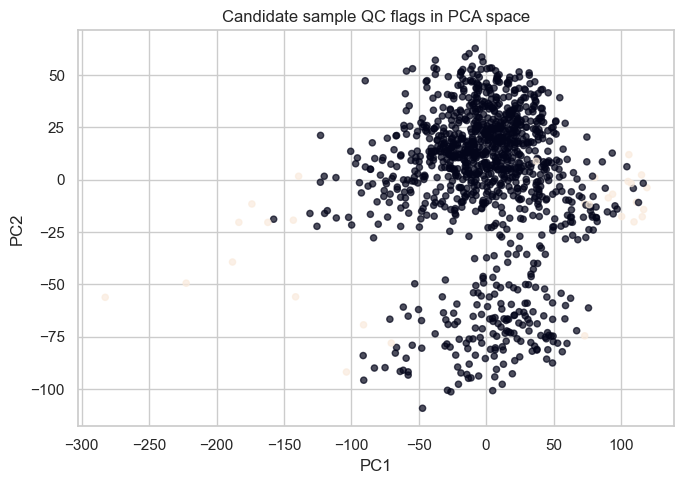

In [9]:
CONTAM = CONFIG["outlier_contamination"]

votes = pd.DataFrame(index=X_train_filt.index)
sample_qc = pd.DataFrame(index=X_train_filt.index)

Xs = StandardScaler().fit_transform(X_train_filt)

# 1) Extreme-gene burden: count genes with very large within-gene z-score
Z = np.abs(stats.zscore(X_train_filt, axis=0, nan_policy="omit"))
extreme_gene_burden = pd.Series((Z > 4.0).sum(axis=1), index=X_train_filt.index)
votes["extreme_gene_burden"] = (extreme_gene_burden >= extreme_gene_burden.quantile(1 - CONTAM)).astype(int)
sample_qc["extreme_gene_burden"] = extreme_gene_burden

# 2) Distance in PCA space
n_pcs_outlier = min(20, X_train_filt.shape[0] - 1, X_train_filt.shape[1])
pcs_outlier = PCA(n_components=n_pcs_outlier, random_state=RNG).fit_transform(Xs)
pc_distance = pd.Series(np.sqrt((pcs_outlier ** 2).sum(axis=1)), index=X_train_filt.index)
votes["pca_distance"] = (pc_distance >= pc_distance.quantile(1 - CONTAM)).astype(int)
sample_qc["pca_distance"] = pc_distance

# 3) Isolation Forest
iso = IsolationForest(contamination=CONTAM, random_state=RNG, n_jobs=-1)
votes["iforest"] = (iso.fit_predict(Xs) == -1).astype(int)

# 4) Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAM)
votes["lof"] = (lof.fit_predict(Xs) == -1).astype(int)

# 5) Total expression burden, robustly
total_expr = X_train_filt.sum(axis=1)
votes["total_expr_mad"] = mad_flag(total_expr).astype(int)
sample_qc["total_expr"] = total_expr

# 6) Number of detected genes, robustly
n_detected = (X_train_filt > CONFIG["detect_expr_threshold"]).sum(axis=1)
votes["n_detected_mad"] = mad_flag(n_detected).astype(int)
sample_qc["n_detected"] = n_detected

votes["n_votes"] = votes.sum(axis=1)

print("Fraction flagged by each detector:")
display(votes.drop(columns="n_votes").mean().round(3).to_frame("fraction_flagged"))

print("Samples by vote count:")
display(votes["n_votes"].value_counts().sort_index().to_frame("n_samples"))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    pcs_outlier[:, 0],
    pcs_outlier[:, 1],
    c=(votes["n_votes"] >= CONFIG["outlier_vote_possible"]).astype(int),
    alpha=0.7,
    s=20,
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Candidate sample QC flags in PCA space")
plt.tight_layout()

print("TP53 rate by outlier-flag status (possible-or-higher):")
display(
    pd.crosstab(
        (votes["n_votes"] >= CONFIG["outlier_vote_possible"]).map({False: "not_flagged", True: "flagged"}),
        y_train,
        normalize="index",
    ).round(3)
)

if lineage_col is not None:
    print(f"Top {lineage_col} groups among possible-or-higher QC flags:")
    display(
        sample_meta.loc[votes.index, [lineage_col]]
        .assign(flagged=lambda d: votes["n_votes"] >= CONFIG["outlier_vote_possible"])
        .loc[lambda d: d["flagged"]]
        [lineage_col]
        .fillna("Unknown")
        .value_counts()
        .head(10)
        .to_frame("n_flagged")
    )

print("Interpretation note: some flag rates are partly induced by the chosen contamination / quantile threshold, so detector agreement matters more than any single detector.")


In [10]:
sure_outliers = votes.index[votes["n_votes"] >= CONFIG["outlier_vote_sure"]]
possible_outliers = votes.index[votes["n_votes"] == CONFIG["outlier_vote_possible"]]

print(f"Sure outliers (>={CONFIG['outlier_vote_sure']} votes): {len(sure_outliers)}")
print(f"Possible outliers (={CONFIG['outlier_vote_possible']} votes): {len(possible_outliers)}")

if len(sure_outliers) > 0:
    print(f"TP53 mutant rate among sure outliers: {y_train.loc[sure_outliers].mean():.1%}")
print(f"TP53 mutant rate in the full training split: {y_train.mean():.1%}")

DROP_SURE_OUTLIERS = False

X_train_drop_outliers = X_train_filt.drop(index=sure_outliers)
y_train_drop_outliers = y_train.drop(index=sure_outliers)

if DROP_SURE_OUTLIERS:
    X_train_clean = X_train_drop_outliers.copy()
    y_train_clean = y_train_drop_outliers.copy()
    print(f"Dropping sure outliers for modeling prep: {X_train_clean.shape[0]} samples remain.")
else:
    X_train_clean = X_train_filt.copy()
    y_train_clean = y_train.copy()
    print("Defaulting to NO sample removal.")
    print("Keep sure outliers for the primary analysis and treat removal as a sensitivity analysis.")

meta_cols_to_show = ["TP53_event_class", "tp53_event_count"]
if lineage_col is not None:
    meta_cols_to_show.append(lineage_col)
if disease_col is not None:
    meta_cols_to_show.append(disease_col)

if len(sure_outliers) > 0:
    display(
        sample_meta.loc[sure_outliers, meta_cols_to_show]
        .join(votes.loc[sure_outliers, ["n_votes"]])
        .sort_values("n_votes", ascending=False)
        .head(20)
    )


Sure outliers (>=4 votes): 9
Possible outliers (=3 votes): 20
TP53 mutant rate among sure outliers: 55.6%
TP53 mutant rate in the full training split: 61.4%
Defaulting to NO sample removal.
Keep sure outliers for the primary analysis and treat removal as a sensitivity analysis.


,TP53_event_class,tp53_event_count,OncotreeLineage,OncotreePrimaryDisease,n_votes
ModelID,,,,,
ACH-001662,missense_or_inframe,1,Breast,Invasive Breast Carcinoma,5
ACH-001388,NaN,0,Breast,Invasive Breast Carcinoma,5
ACH-001400,missense_or_inframe,1,Vulva/Vagina,Squamous Cell Carcinoma of the Vulva/Vagina,4
ACH-003476,missense_or_inframe,1,Esophagus/Stomach,Esophageal Squamous Cell Carcinoma,4
ACH-001064,missense_or_inframe,1,Lymphoid,Mature B-Cell Neoplasms,4
ACH-001687,NaN,0,Kidney,Renal Cell Carcinoma,4
ACH-003106,NaN,0,Lymphoid,Mature B-Cell Neoplasms,4
ACH-003100,NaN,0,Lymphoid,Mature B-Cell Neoplasms,4
ACH-002170,lof_or_splice,1,Lung,Lung Neuroendocrine Tumor,4


## 6. Feature representations for downstream models

We prepare two representations:

### A. Selected gene set
This is the main interpretable feature set. It is the union of:
- genes with reproducible univariate TP53 signal
- curated TP53 pathway / target genes present in the data

### B. PCA baseline
This is an alternative low-dimensional representation for benchmarking.
It is **not** mixed into the selected gene set.

In [11]:
corr_clean = corr_against_binary(X_train_clean, y_train_clean, method="pearson").join(
    corr_against_binary(X_train_clean, y_train_clean, method="spearman")
)
corr_clean["abs_pearson_r"] = corr_clean["pearson_r"].abs()
corr_clean["abs_spearman_r"] = corr_clean["spearman_r"].abs()

corr_ranked = corr_clean.loc[
    (corr_clean["pearson_p_bh"] <= CONFIG["corr_alpha"])
    & (corr_clean["spearman_p_bh"] <= CONFIG["corr_alpha"])
    & (corr_clean["abs_pearson_r"] >= CONFIG["corr_min_abs_r"])
].sort_values("abs_pearson_r", ascending=False)

n_before_cap = len(corr_ranked)
set_corr = set(corr_ranked.head(CONFIG["max_corr_features"]).index)

print(f"Genes passing correlation thresholds before cap: {n_before_cap}")
print(f"Correlation-selected genes after cap:          {len(set_corr)}")
print(f"Selection rule: BH <= {CONFIG['corr_alpha']} in both tests and |Pearson r| >= {CONFIG['corr_min_abs_r']}")
print(f"Cap applied: top {CONFIG['max_corr_features']} by |Pearson r|")

display(
    corr_ranked.head(25)[["pearson_r", "pearson_p_bh", "spearman_r", "spearman_p_bh"]].round(4)
)

print("Important: for cross-validation-heavy model selection, redo this feature selection inside each training fold rather than once globally.")


Genes passing correlation thresholds before cap: 2232
Correlation-selected genes after cap:          300
Selection rule: BH <= 0.05 in both tests and |Pearson r| >= 0.15
Cap applied: top 300 by |Pearson r|


,pearson_r,pearson_p_bh,spearman_r,spearman_p_bh
EDA2R,-0.6215,0.0,-0.5581,0.0
MDM2,-0.5366,0.0,-0.5616,0.0
RPS27L,-0.5278,0.0,-0.5343,0.0
ZMAT3,-0.5267,0.0,-0.5192,0.0
CDKN1A,-0.5188,0.0,-0.5508,0.0
RRM2B,-0.4187,0.0,-0.4141,0.0
SESN1,-0.4142,0.0,-0.4348,0.0
BAX,-0.4073,0.0,-0.4090,0.0
PTCHD4,-0.4038,0.0,-0.4366,0.0
FDXR,-0.3986,0.0,-0.4008,0.0


Important: for cross-validation-heavy model selection, redo this feature selection inside each training fold rather than once globally.


PCA components needed to reach 80% variance: 201
PCA baseline components kept:               100
Variance explained by kept PCs:             0.655
Note: the max_pca_components cap stopped us before 80% variance explained.
These PCs are for an alternative baseline model, not for gene selection.


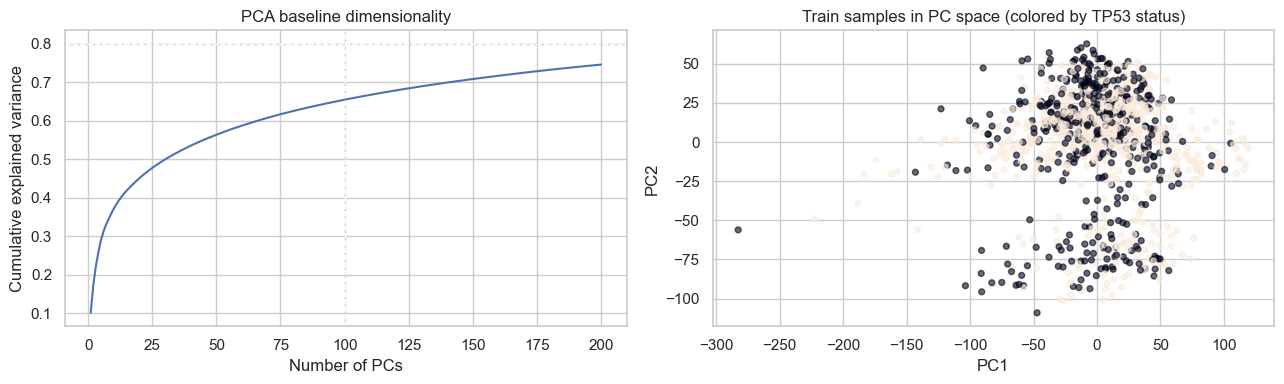

In [12]:
scaler_pca = StandardScaler().fit(X_train_clean)

X_train_scaled = scaler_pca.transform(X_train_clean)
X_val_scaled = scaler_pca.transform(X_val_filt[X_train_clean.columns])
X_test_scaled = scaler_pca.transform(X_test_filt[X_train_clean.columns])

max_full_pcs = min(200, X_train_clean.shape[0] - 1, X_train_clean.shape[1])
pca_probe = PCA(n_components=max_full_pcs, random_state=RNG).fit(X_train_scaled)
cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
n_pca_80 = int(np.searchsorted(cumvar, 0.80) + 1)
n_pca = min(n_pca_80, CONFIG["max_pca_components"])

pca_baseline = PCA(n_components=n_pca, random_state=RNG).fit(X_train_scaled)

pc_cols = [f"PC{i+1}" for i in range(n_pca)]
X_train_pca = pd.DataFrame(pca_baseline.transform(X_train_scaled), index=X_train_clean.index, columns=pc_cols)
X_val_pca = pd.DataFrame(pca_baseline.transform(X_val_scaled), index=X_val_filt.index, columns=pc_cols)
X_test_pca = pd.DataFrame(pca_baseline.transform(X_test_scaled), index=X_test_filt.index, columns=pc_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, len(cumvar) + 1), cumvar)
axes[0].axhline(0.80, linestyle="--", linewidth=1)
axes[0].axvline(n_pca, linestyle="--", linewidth=1)
axes[0].set_xlabel("Number of PCs")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("PCA baseline dimensionality")

axes[1].scatter(
    X_train_pca["PC1"],
    X_train_pca["PC2"],
    c=y_train_clean,
    alpha=0.6,
    s=18,
)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Train samples in PC space (colored by TP53 status)")

plt.tight_layout()

print(f"PCA components needed to reach 80% variance: {n_pca_80}")
print(f"PCA baseline components kept:               {n_pca}")
print(f"Variance explained by kept PCs:             {pca_baseline.explained_variance_ratio_.sum():.3f}")
if n_pca < n_pca_80:
    print("Note: the max_pca_components cap stopped us before 80% variance explained.")
print("These PCs are for an alternative baseline model, not for gene selection.")


In [13]:
TP53_TARGETS = {
    # Curated direct / commonly reported TP53-responsive genes.
    # Move this to a versioned text file later if you want cleaner provenance.
    "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
    "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
    "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
    "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
    "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
    "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
}

target_aliases = {
    "WIG1": "ZMAT3",
}

targets_present = set()
for gene in TP53_TARGETS:
    if gene in X_train_clean.columns:
        targets_present.add(gene)
    elif gene in target_aliases and target_aliases[gene] in X_train_clean.columns:
        targets_present.add(target_aliases[gene])

set_targets = targets_present

print(f"TP53 target genes present after filtering: {len(set_targets)}")
print(f"Already picked by correlation screen:      {len(set_targets & set_corr)}")

display(pd.Series(sorted(set_targets), name="TP53_target_gene").to_frame())


TP53 target genes present after filtering: 49
Already picked by correlation screen:      18


,TP53_target_gene
0,APAF1
1,ATF3
2,BAK1
3,BAX
4,BBC3
5,BID
6,BTG2
7,CASP6
8,CCNG1
9,CCNG2


In [14]:
selected = sorted(set_corr | set_targets)

selected_manifest = pd.DataFrame(index=selected)
selected_manifest["from_correlation"] = selected_manifest.index.isin(set_corr)
selected_manifest["from_tp53_target_list"] = selected_manifest.index.isin(set_targets)
selected_manifest["pearson_r"] = corr_clean.reindex(selected_manifest.index)["pearson_r"]
selected_manifest["spearman_r"] = corr_clean.reindex(selected_manifest.index)["spearman_r"]
selected_manifest["abs_pearson_r"] = selected_manifest["pearson_r"].abs()
selected_manifest["corr_rank"] = selected_manifest["abs_pearson_r"].rank(method="dense", ascending=False)

print(f"Final selected gene features: {len(selected)} (from {X_train_clean.shape[1]:,} filtered genes)")
print(f"Correlation only: {len(set_corr - set_targets)}")
print(f"Target-list only: {len(set_targets - set_corr)}")
print(f"Overlap:          {len(set_corr & set_targets)}")

display(
    selected_manifest
    .assign(tp53_target=lambda d: d.index.isin(set_targets))
    .sort_values("abs_pearson_r", ascending=False)
    .head(30)
    .round(4)
)


Final selected gene features: 331 (from 17,764 filtered genes)
Correlation only: 282
Target-list only: 31
Overlap:          18


,from_correlation,from_tp53_target_list,pearson_r,spearman_r,abs_pearson_r,corr_rank,tp53_target
EDA2R,True,True,-0.6215,-0.5581,0.6215,1.0,True
MDM2,True,True,-0.5366,-0.5616,0.5366,2.0,True
RPS27L,True,True,-0.5278,-0.5343,0.5278,3.0,True
ZMAT3,True,True,-0.5267,-0.5192,0.5267,4.0,True
CDKN1A,True,True,-0.5188,-0.5508,0.5188,5.0,True
RRM2B,True,True,-0.4187,-0.4141,0.4187,6.0,True
SESN1,True,True,-0.4142,-0.4348,0.4142,7.0,True
BAX,True,True,-0.4073,-0.4090,0.4073,8.0,True
PTCHD4,True,False,-0.4038,-0.4366,0.4038,9.0,False
FDXR,True,True,-0.3986,-0.4008,0.3986,10.0,True


## 7. Lineage confounding check

CCLE is strongly structured by lineage / tissue. A model can look good by learning lineage-associated expression patterns instead of TP53 biology.

Here we:
- summarize TP53 mutation rate by lineage in the training split
- visualize how much rates differ across major groups
- fit a simple **lineage-only baseline** to see how predictive lineage is by itself

Overall train TP53 mutation rate: 61.4%


,n,tp53_rate
OncotreeLineage,,
Lung,148,0.905
Lymphoid,128,0.484
Skin,77,0.325
CNS/Brain,68,0.647
Esophagus/Stomach,56,0.857
Bowel,54,0.796
Myeloid,50,0.580
Breast,50,0.800
Head and Neck,50,0.880


Validation performance for a lineage-only baseline:
  AUROC: 0.677
  AUPRC: 0.726
Treat this as a benchmark any RNA model should beat convincingly, not just barely.


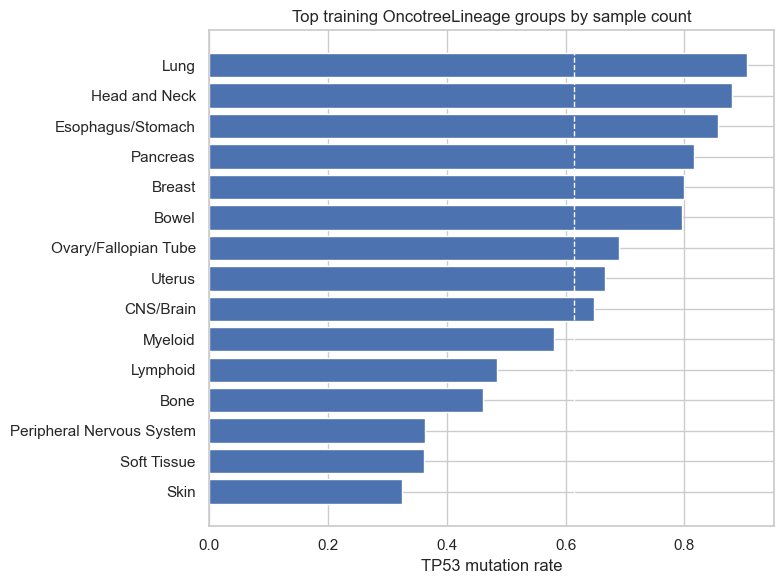

In [15]:
if lineage_col is None:
    print("No lineage column found in Model.csv; skipping lineage confounding check.")
else:
    lineage_train = sample_meta.loc[X_train.index, [lineage_col]].copy()
    lineage_train[lineage_col] = lineage_train[lineage_col].fillna("Unknown")
    lineage_train["TP53_mut"] = y_train

    lineage_summary = (
        lineage_train.groupby(lineage_col)
        .agg(n=("TP53_mut", "size"), tp53_rate=("TP53_mut", "mean"))
        .sort_values("n", ascending=False)
    )

    print(f"Overall train TP53 mutation rate: {y_train.mean():.1%}")
    display(lineage_summary.head(20).round(3))

    major_lineages = lineage_summary.loc[lineage_summary["n"] >= CONFIG["min_lineage_n_report"]].index
    train_lineage_collapsed = sample_meta.loc[X_train.index, [lineage_col]].fillna("Unknown").copy()
    val_lineage_collapsed = sample_meta.loc[X_val.index, [lineage_col]].fillna("Unknown").copy()

    train_lineage_collapsed[lineage_col] = train_lineage_collapsed[lineage_col].where(
        train_lineage_collapsed[lineage_col].isin(major_lineages),
        other="Other",
    )
    val_lineage_collapsed[lineage_col] = val_lineage_collapsed[lineage_col].where(
        val_lineage_collapsed[lineage_col].isin(major_lineages),
        other="Other",
    )

    top_lineages = lineage_summary.head(15).sort_values("tp53_rate")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_lineages.index.astype(str), top_lineages["tp53_rate"])
    ax.axvline(y_train.mean(), linestyle="--", linewidth=1)
    ax.set_xlabel("TP53 mutation rate")
    ax.set_title(f"Top training {lineage_col} groups by sample count")
    plt.tight_layout()

    enc = OneHotEncoder(handle_unknown="ignore")
    X_lineage_train = enc.fit_transform(train_lineage_collapsed[[lineage_col]])
    X_lineage_val = enc.transform(val_lineage_collapsed[[lineage_col]])

    lineage_only_model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RNG,
    )
    lineage_only_model.fit(X_lineage_train, y_train)
    val_prob = lineage_only_model.predict_proba(X_lineage_val)[:, 1]

    print("Validation performance for a lineage-only baseline:")
    print(f"  AUROC: {roc_auc_score(y_val, val_prob):.3f}")
    print(f"  AUPRC: {average_precision_score(y_val, val_prob):.3f}")
    print("Treat this as a benchmark any RNA model should beat convincingly, not just barely.")


## 8. Save processed artifacts for downstream notebooks

Next notebooks will load these directly — no need to re-run EDA.

In [16]:
X_train_final = X_train_clean[selected]
X_val_final = X_val_filt[selected]
X_test_final = X_test_filt[selected]

artifacts_written = []

def save_parquet(df, filename):
    path = OUT_DIR / filename
    df.to_parquet(path)
    artifacts_written.append(path)

def save_csv(obj, filename, index=False):
    path = OUT_DIR / filename
    obj.to_csv(path, index=index)
    artifacts_written.append(path)

save_parquet(X_train_final, "ccle_X_train_selected.parquet")
save_parquet(X_val_final, "ccle_X_val_selected.parquet")
save_parquet(X_test_final, "ccle_X_test_selected.parquet")

save_parquet(X_train_pca, "ccle_X_train_pca.parquet")
save_parquet(X_val_pca, "ccle_X_val_pca.parquet")
save_parquet(X_test_pca, "ccle_X_test_pca.parquet")

save_parquet(y_train_clean.rename("TP53_mut").to_frame(), "ccle_y_train.parquet")
save_parquet(y_val.rename("TP53_mut").to_frame(), "ccle_y_val.parquet")
save_parquet(y_test.rename("TP53_mut").to_frame(), "ccle_y_test.parquet")

save_parquet(y_all.rename("TP53_mut_any").to_frame(), "ccle_y_all_any.parquet")
save_parquet(y_all_nonsyn.rename("TP53_mut_nonsyn").to_frame(), "ccle_y_all_nonsyn.parquet")
save_parquet(y_all_lof.rename("TP53_mut_lof").to_frame(), "ccle_y_all_lof.parquet")
save_parquet(mut_type.to_frame(), "ccle_mut_type.parquet")

save_parquet(sample_meta, "ccle_sample_metadata.parquet")
save_parquet(split_membership.rename("split").to_frame(), "ccle_split_membership.parquet")

save_parquet(X_train, "ccle_X_train_full_raw.parquet")
save_parquet(X_train_filt, "ccle_X_train_full_filtered.parquet")

save_parquet(votes, "ccle_outlier_votes.parquet")
save_parquet(gene_filter_qc, "ccle_gene_filter_qc.parquet")
save_parquet(corr, "ccle_corr_train_filtered.parquet")
save_parquet(corr_clean, "ccle_corr_train_modeling.parquet")
save_parquet(selected_manifest, "ccle_selected_gene_manifest.parquet")

save_csv(pd.Series(selected, name="gene"), "ccle_selected_genes.txt", index=False)
save_csv(pd.Series(sure_outliers, name="ModelID"), "ccle_sure_outliers.txt", index=False)
save_csv(pd.Series(possible_outliers, name="ModelID"), "ccle_possible_outliers.txt", index=False)

config_path = OUT_DIR / "ccle_eda_config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)
artifacts_written.append(config_path)

print(f"Saved {len(artifacts_written)} artifacts to {OUT_DIR.resolve()}:")
for f in artifacts_written:
    print(f"  {f.name:35s} {f.stat().st_size / 1e6:8.2f} MB")


Saved 26 artifacts to /Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/processed:
  ccle_X_train_selected.parquet           3.00 MB
  ccle_X_val_selected.parquet             0.71 MB
  ccle_X_test_selected.parquet            0.71 MB
  ccle_X_train_pca.parquet                0.93 MB
  ccle_X_val_pca.parquet                  0.22 MB
  ccle_X_test_pca.parquet                 0.22 MB
  ccle_y_train.parquet                    0.01 MB
  ccle_y_val.parquet                      0.00 MB
  ccle_y_test.parquet                     0.00 MB
  ccle_y_all_any.parquet                  0.01 MB
  ccle_y_all_nonsyn.parquet               0.01 MB
  ccle_y_all_lof.parquet                  0.01 MB
  ccle_mut_type.parquet                   0.01 MB
  ccle_sample_metadata.parquet            0.04 MB
  ccle_split_membership.parquet           0.01 MB
  ccle_X_train_full_raw.parquet         151.81 MB
  ccle_X_train_full_filtered.parquet    149.31 MB
  ccle_outlier_votes.parquet              0.01 MB
  ccle_gen